In [1]:
# Pandas Dataframe Master
# 1. Import libraries
import pandas as pd
import numpy as np

# 2. Create DataFrames

employees = pd.DataFrame({
    'emp_id': [1, 2, 3, 4],
    'name': ['Ali', 'Sara', 'Ahmed', 'Ayesha'],
    'dept_id': [101, 102, 101, 103]
})

departments = pd.DataFrame({
    'dept_id': [101, 102, 103],
    'dept_name': ['HR', 'IT', 'Finance']
})

salaries = pd.DataFrame({
    'emp_id': [1, 2, 3, 4],
    'salary': [50000, 70000, 90000, 60000]
})

# 3. Merging

inner_join = pd.merge(employees, departments, on='dept_id', how='inner')
left_join = pd.merge(employees, departments, on='dept_id', how='left')
outer_join = pd.merge(employees, departments, on='dept_id', how='outer')

print("Inner Join:\n", inner_join)
print("Left Join:\n", left_join)
print("Outer Join:\n", outer_join)

# 4. Concatenate new employees
new_emp = pd.DataFrame({
    'emp_id': [5],
    'name': ['Usman'],
    'dept_id': [102]
})

employees = pd.concat([employees, new_emp], ignore_index=True)

# 5. Merge employees with salaries
emp_salary = pd.merge(employees, salaries, on='emp_id', how='left')

# 6. Groupby average salary
avg_salary = emp_salary.groupby('dept_id')['salary'].mean()
print("Average Salary by Dept:\n", avg_salary)

# 7. Salary bins
bins = [0, 60000, 80000, 100000]
labels = ['Low', 'Medium', 'High']

emp_salary['salary_category'] = pd.cut(emp_salary['salary'], bins=bins, labels=labels)

# 8. Save to CSV
emp_salary.to_csv('employee_summary.csv', index=False)

print("Final Data:\n", emp_salary)

Inner Join:
    emp_id    name  dept_id dept_name
0       1     Ali      101        HR
1       2    Sara      102        IT
2       3   Ahmed      101        HR
3       4  Ayesha      103   Finance
Left Join:
    emp_id    name  dept_id dept_name
0       1     Ali      101        HR
1       2    Sara      102        IT
2       3   Ahmed      101        HR
3       4  Ayesha      103   Finance
Outer Join:
    emp_id    name  dept_id dept_name
0       1     Ali      101        HR
1       3   Ahmed      101        HR
2       2    Sara      102        IT
3       4  Ayesha      103   Finance
Average Salary by Dept:
 dept_id
101    70000.0
102    70000.0
103    60000.0
Name: salary, dtype: float64
Final Data:
    emp_id    name  dept_id   salary salary_category
0       1     Ali      101  50000.0             Low
1       2    Sara      102  70000.0          Medium
2       3   Ahmed      101  90000.0            High
3       4  Ayesha      103  60000.0             Low
4       5   Usman      102 

In [9]:
# Data Visualization
# 1. import matplotlib.pyplot as plt
import seaborn as sns

# 2. Create dataset
sales = pd.DataFrame({
    'month': ['Jan','Feb','Mar','Apr','May'],
    'product_a': [100,120,130,150,170],
    'product_b': [80,90,100,110,120],
    'product_c': [60,70,80,90,100],
    'region': ['North','South','East','West','North']
})



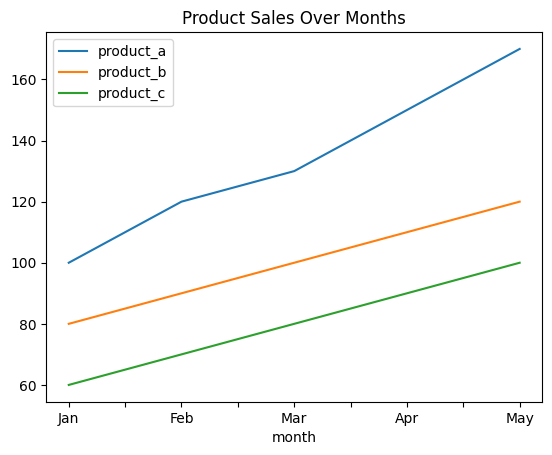

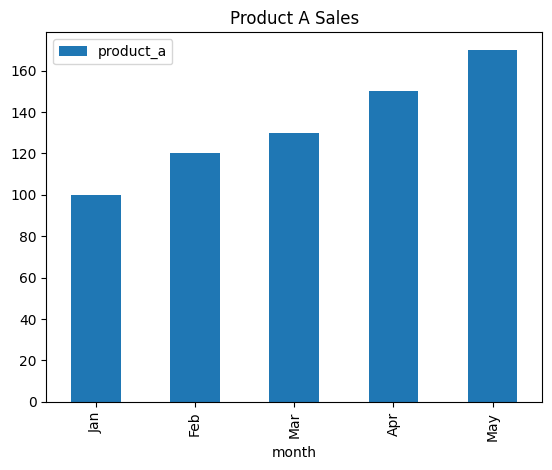

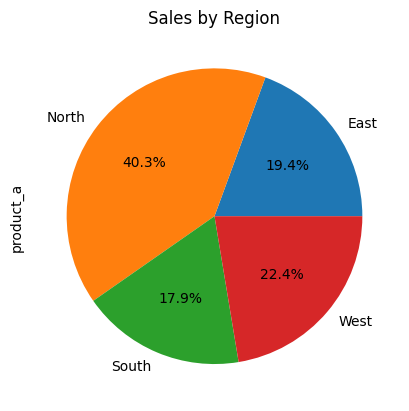

In [8]:
# 3. Line plot
sales.set_index('month')[['product_a','product_b','product_c']].plot()
plt.title("Product Sales Over Months")
plt.show()

# Bar plot
sales.plot(x='month', y='product_a', kind='bar')
plt.title("Product A Sales")
plt.show()

# Pie chart
sales.groupby('region')['product_a'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Region")
plt.show()

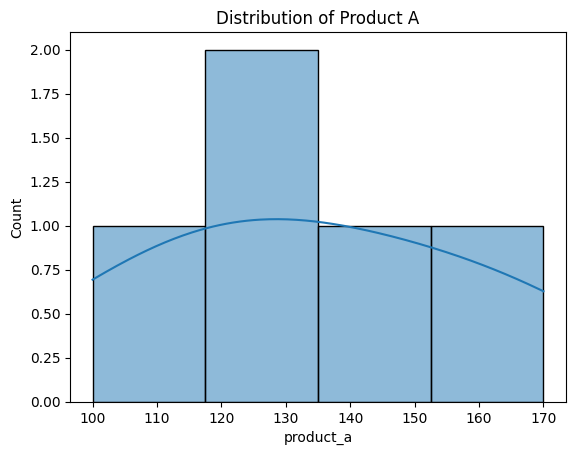

In [11]:
# 4. Seaborn Distribution
sns.histplot(sales['product_a'], kde=True)
plt.title("Distribution of Product A")
plt.show()

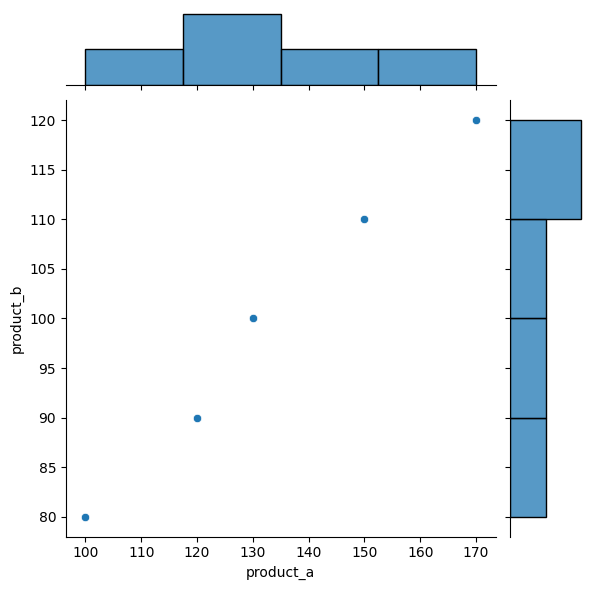

In [10]:
sns.jointplot(x='product_a', y='product_b', data=sales)
plt.show()

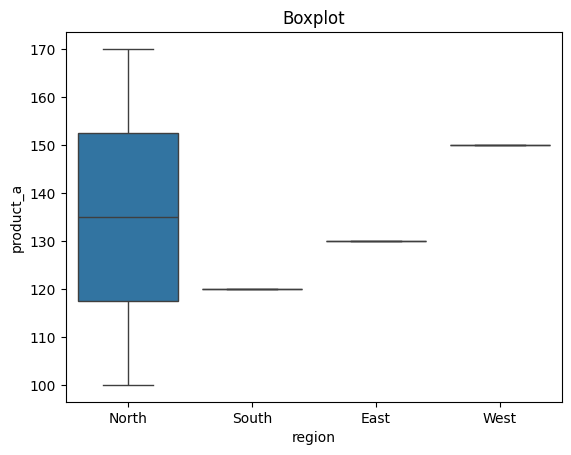

In [13]:
# 5. Categorical plots
sns.boxplot(x='region', y='product_a', data=sales)
plt.title("Boxplot")
plt.show()

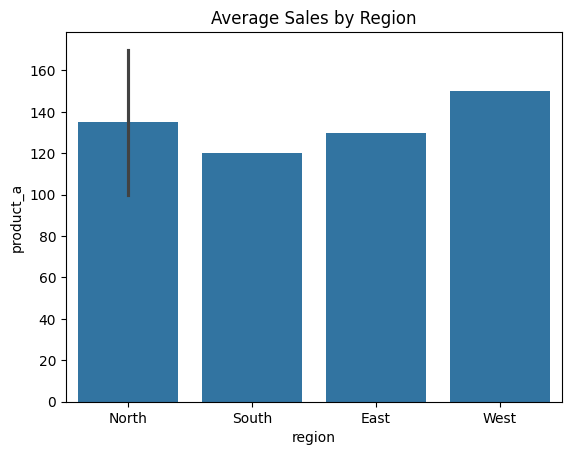

In [12]:
sns.barplot(x='region', y='product_a', data=sales)
plt.title("Average Sales by Region")
plt.show()

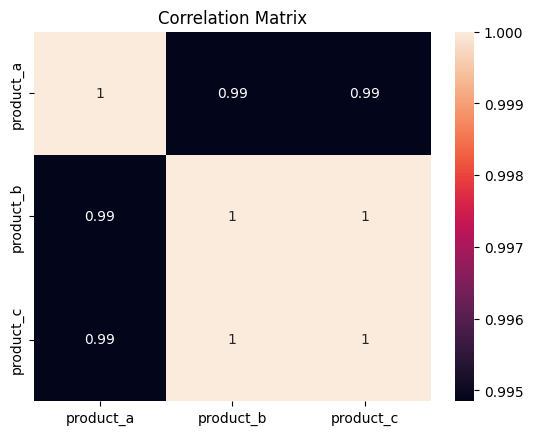

In [4]:
# 6. Heatmap
corr = sales[['product_a','product_b','product_c']].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

Epoch 0, Cost: 3887.5
Epoch 100, Cost: 57.89916621441546
Epoch 200, Cost: 26.83356096045929
Epoch 300, Cost: 12.875800196811417
Epoch 400, Cost: 6.6045853293521795
Epoch 500, Cost: 3.786931654110175
Epoch 600, Cost: 2.520961279725384
Epoch 700, Cost: 1.9521614293738858
Epoch 800, Cost: 1.6965999436502628
Epoch 900, Cost: 1.5817762970812532
Final slope (m): 7.461363773461176
Final intercept (b): 26.333616721495858
Prediction for 4.5 hours: 59.90975370207115
Prediction for 7.5 hours: 82.29384502245469


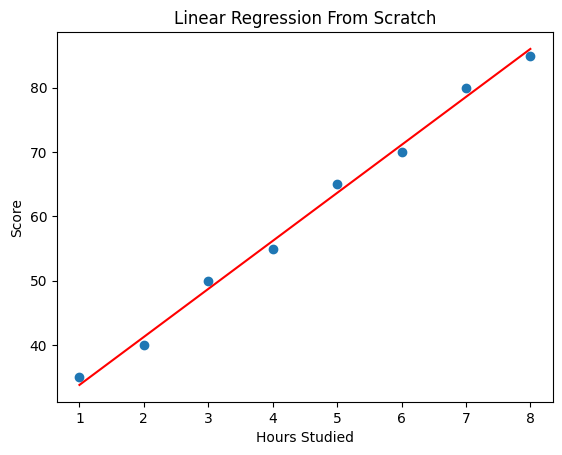

In [14]:
# Linear Regression
# 1. import numpy as np
import matplotlib.pyplot as plt

# 2. Dataset (Hours vs Scores)
X = np.array([1,2,3,4,5,6,7,8])
y = np.array([35,40,50,55,65,70,80,85])

# 3. Initialize
m = 0
b = 0
lr = 0.01
epochs = 1000
n = len(X)

# Training loop
for i in range(epochs):

    y_pred = m*X + b

    # Cost (MSE)
    cost = (1/n) * np.sum((y - y_pred)**2)

    # Gradients
    m_grad = (-2/n) * np.sum(X * (y - y_pred))
    b_grad = (-2/n) * np.sum(y - y_pred)

    # Update
    m = m - lr * m_grad
    b = b - lr * b_grad

    if i % 100 == 0:
        print(f"Epoch {i}, Cost: {cost}")

# Final values
print("Final slope (m):", m)
print("Final intercept (b):", b)

# Predictions
print("Prediction for 4.5 hours:", m*4.5 + b)
print("Prediction for 7.5 hours:", m*7.5 + b)

# Plot
plt.scatter(X, y)
plt.plot(X, m*X + b, color='red')
plt.title("Linear Regression From Scratch")
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.show()